```
Linear Regression

Assumptions:
 1. Linearity
 2. Independence of Errors (Durbin-Watson)
 3. Homoscedasticity (Constant Variance)
 4. Normality of Residuals
 5. No Multicollinearity (VIF)

```

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler 
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


In [47]:
np.random.seed(42)

In [49]:
# Generate random training data
n = 300

# Three features
X1 = np.random.uniform(1, 10, n) # Feature 1 (continuous)
X2 = np.random.uniform(1, 5, n)  # Feature 2 (continuous)
X3 = np.random.normal(5, 2, n)   # Feature 3 (normal)

# True relationship y = 3 + 2X1 -1.5X2 + 0.8X3 + noise
noise = np.random.normal(0, 2, n)
y = 3 + 2 * X1 - 1.5 * X2 + 0.8 *X3 + noise

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "y": y
})

print(f"Dataset shape: {df.shape}\n")
print(f"Features:    : X1, X2, X3\n")
print(f"Target:      : y\n\n")
print(df.head().to_string(index = False))

Dataset shape: (300, 4)

Features:    : X1, X2, X3

Target:      : y


      X1       X2       X3         y
4.370861 1.206727 3.939485 11.184422
9.556429 3.125419 3.414254 25.420897
7.587945 3.162540 4.785939 18.247467
6.387926 3.549720 2.929515 13.164558
2.404168 3.904365 3.892701  3.349233


In [51]:
# Fit the model

X = df[["X1", "X2", "X3"]].values
X_sm = sm.add_constant(X)   # add intercept for satsmodels

model_sm = sm.OLS(y, X_sm).fit()
fitted_values = model_sm.fittedvalues
residuals = model_sm.resid

print(f"Model Summary\n")
print(model_sm.summary())

Model Summary

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     950.0
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          1.59e-151
Time:                        21:21:59   Log-Likelihood:                -617.45
No. Observations:                 300   AIC:                             1243.
Df Residuals:                     296   BIC:                             1258.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6462      0.492     

- --------------------------------------------------------------------------------

```
Assumption 1: Lineariity

Test: Scatter plots (X vs y) + Residuals Vs Fitted plot
Rule: Residuals should scatter randomly around 0 ( no pattern )
```

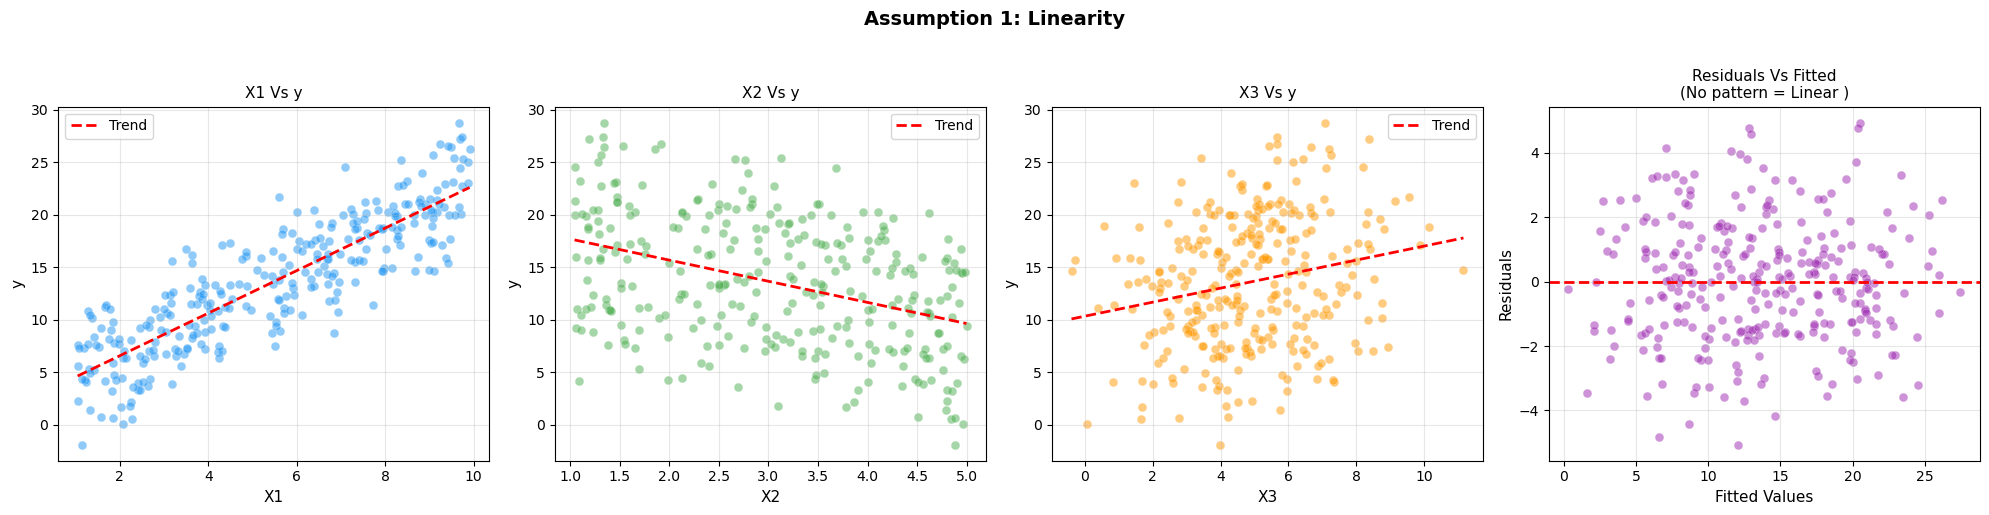

In [73]:
def test_linearity(df, fitted_values, residuals):
    fig, axes = plt.subplots(1, 4, figsize = (20, 5))
    fig.suptitle("Assumption 1: Linearity", fontsize = 14, fontweight = "bold", y = 1.02)

    features = ["X1", "X2", "X3"]
    colors = ["#2196F3", "#4CAF50", "#FF9800"]

    for i, (feat, color) in enumerate(zip(features, colors)):
        axes[i].scatter(df[feat], df["y"], alpha = 0.5, color = color, edgecolors= "white", linewidth = 0.3, s = 40)
        # fit a trend line
        z = np.polyfit(df[feat], df["y"], 1)
        p = np.poly1d(z)
        xs = np.linspace(df[feat].min(), df[feat].max(), 100)
        axes[i].plot(xs, p(xs), color = "red", linewidth = 2, linestyle = "--", label = "Trend")
        axes[i].set_xlabel(feat, fontsize = 11)
        axes[i].set_ylabel("y", fontsize = 11)
        axes[i].set_title(f"{feat} Vs y", fontsize = 11)
        axes[i].legend()
        axes[i].grid(True, alpha = 0.3)


    # Residuals VS fitted
    axes[3].scatter(fitted_values, residuals, alpha = 0.5, color = "#9C27B0",
                    edgecolor = "white", linewidth = 0.3, s = 40)
    axes[3].axhline(0, color = "red", linewidth = 2, linestyle = "--")
    axes[3].set_xlabel("Fitted Values", fontsize = 11)
    axes[3].set_ylabel("Residuals", fontsize = 11)
    axes[3].set_title("Residuals Vs Fitted\n(No pattern = Linear )", fontsize = 11)
    axes[3].grid(True, alpha = 0.3)

        

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    test_linearity(df, fitted_values, residuals)

- ---------------------------------------------------------------------------------

```
Assumption 2: Independence of errors

Test: Durbin- Watson statistic
Rule: DW ~ 2   ---> no autocorrelation
      DW < 1.5 ---> positive autocorrelation (problem)
      DW > 2.5 ---> negative autocorrelation (problem)

```

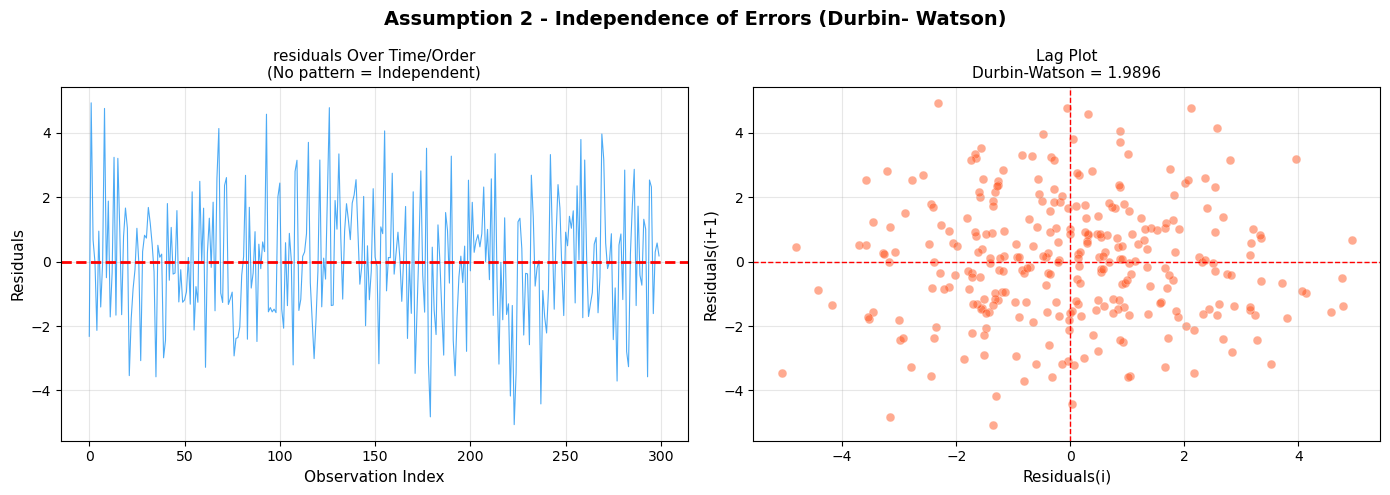




Result: No significant autocorrelation detected (DW = 2)
Interpretation: DW close to 2 = errors are independent.


In [95]:
def test_independence(residuals):
    dw_stat = durbin_watson(residuals)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Assumption 2 - Independence of Errors (Durbin- Watson)", fontsize = 14, 
                 fontweight = "bold")

    # Residuals over observations index
    axes[0].plot(range(len(residuals)), residuals, color = "#2196F3", linewidth = 0.8,
                 alpha = 0.8)
    axes[0].axhline(0, color = "red", linewidth = 2, linestyle = "--")
    axes[0].set_xlabel("Observation Index", fontsize = 11)
    axes[0].set_ylabel("Residuals", fontsize = 11)
    axes[0].set_title("residuals Over Time/Order\n(No pattern = Independent)",
                      fontsize = 11)
    axes[0].grid(True, alpha = 0.3)


    # Lag plot: residual[i] vs residual[i-1]
    axes[1].scatter(residuals[:-1], residuals[1:], alpha = 0.5, color = "#FF5722",
                    edgecolor = "white", linewidth = 0.3, s = 40)
    axes[1].axhline(0, color = "red", linewidth = 1, linestyle = "--")
    axes[1].axvline(0, color = "red", linewidth = 1, linestyle = "--")
    axes[1].set_xlabel("Residuals(i)", fontsize = 11)
    axes[1].set_ylabel("Residuals(i+1)", fontsize = 11)
    axes[1].set_title(f"Lag Plot\nDurbin-Watson = {dw_stat:.4f}", fontsize = 11)
    axes[1].grid(True, alpha = 0.3)


    plt.tight_layout()
    plt.show()


    if 1.5 <= dw_stat <= 2.5:
        print("\n\n\nResult: No significant autocorrelation detected (DW = 2)")
    elif dw_stat < 1.5:
        print(" Result: Positive autocorrelation detected (DW < 1.5)")

    else:
        print("Result: Negative autocorrelation detected (DW > 2.5)")
    print("Interpretation: DW close to 2 = errors are independent.")
    return dw_stat


if __name__ == "__main__":
    test_independence(residuals)
                      

    

- --------------------------------------------------------------------------------

```
Assumption 3: Homoscedasticity ( Constant Variance)

Test: Breusch-Pagan test + Scale - Location plot
Rule: p-value > 0.05 --> Failt to reject --> homoscedastic

```

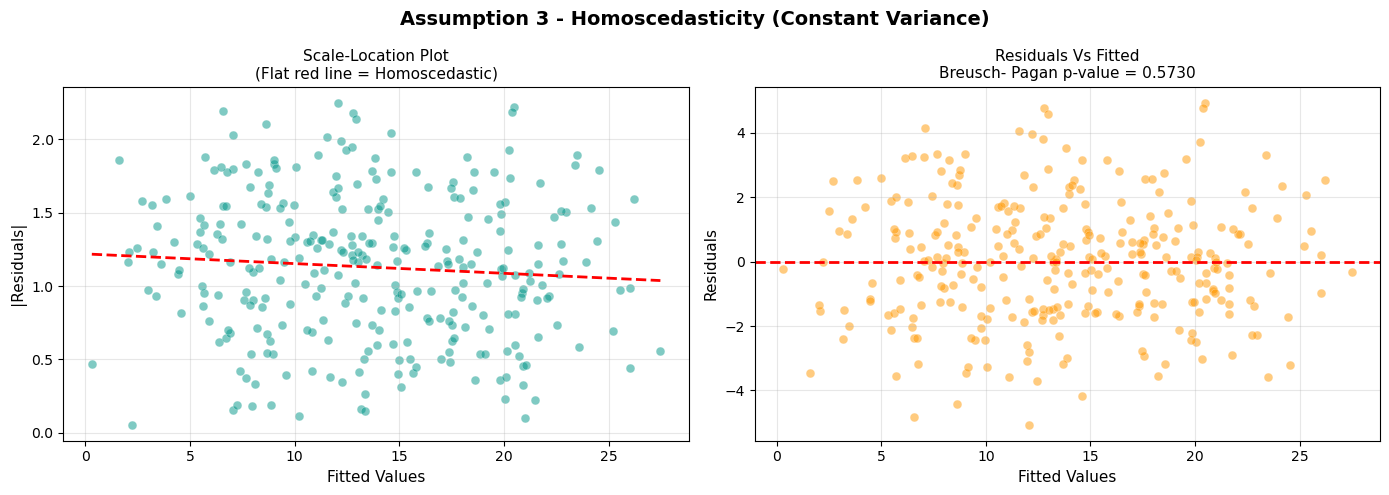

 Breusch - Pagan LM Statistic: 1.9969
 Breusch - Pagan p - value:    0.5730



Result: Homoscedastic - constant variance ( p > 0.05)
Interpretation: p > 0.05 means we fail to reject H. (constant variance).


In [115]:
def test_homoscedasticity(X_sm, fitted_values, residuals):
    # Breusch- Pagan test
    bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_sm)
    fig, axes = plt.subplots(1, 2, figsize = (14, 5))
    fig.suptitle("Assumption 3 - Homoscedasticity (Constant Variance)", fontsize = 14,
                 fontweight = "bold")

    # Scale- Location plot
    sqrt_abs_resid = np.sqrt(np.abs(residuals))
    axes[0].scatter(fitted_values, sqrt_abs_resid, alpha = 0.5, color = "#009688",
                    edgecolor = "white", linewidth = 0.3, s = 40)
    z = np.polyfit(fitted_values, sqrt_abs_resid, 1)
    p = np.poly1d(z)
    xs = np.linspace(fitted_values.min(), fitted_values.max(), 100)
    axes[0].plot(xs, p(xs), color = "red", linewidth  = 2, linestyle = "--")
    axes[0].set_xlabel("Fitted Values", fontsize = 11)
    axes[0].set_ylabel("|Residuals|", fontsize = 11)
    axes[0].set_title("Scale-Location Plot\n(Flat red line = Homoscedastic)",
                      fontsize = 11)
    axes[0].grid(True, alpha = 0.3)


    # Residuals Vs fitted (spread check)
    axes[1].scatter(fitted_values, residuals, alpha = 0.5, color = "#FF9800",
                    edgecolor = "white", linewidth = 0.3, s = 40)
    axes[1].axhline(0, color = "red", linewidth = 2, linestyle = "--")
    axes[1].set_xlabel("Fitted Values", fontsize = 11)
    axes[1].set_ylabel("Residuals", fontsize = 11)
    axes[1].set_title(f"Residuals Vs Fitted\nBreusch- Pagan p-value = {bp_p:.4f}",
                  fontsize = 11)
    axes[1].grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.show()


    print(f" Breusch - Pagan LM Statistic: {bp_lm:.4f}")
    print(f" Breusch - Pagan p - value:    {bp_p:.4f}")
    if bp_p > 0.05:
        print("\n\n\nResult: Homoscedastic - constant variance ( p > 0.05)")
    else:
        print("Result: Heteroscedastic - variance is not constant ( p <= 0.05)")
    print("Interpretation: p > 0.05 means we fail to reject H. (constant variance).")
    return bp_p

if __name__== "__main__":
    test_homoscedasticity(X_sm, fitted_values, residuals)
    
    

- ---------------------------------------------------------------------------------

```

Assumptions 4: Normality of Residuals

Test: Shapiro-Wilk test + Q-Q plot + Histogram
Rule: p-value > 0.05 --> residuals are normally distributed

```

In [ ]:
def test_normality(residuals):
    stat, p_value = stats.shapiro(residuals)
    fig, axes = plt.subplots(1, 3, figsize = (18, 5))
    fig.suptitle("Assumption 4 - Normality of Residuals", fontsize = 14,
               fontweight = "bold")
    